# Model Evaluation

**Team Member:** Annalena Salchegger

This notebook evaluates the trained keypoint detection model on the test set.

In [11]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, models
from PIL import Image
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import json

## Configuration

In [12]:
DATA_DIR      = Path('/home/azureuser/cloudfiles/code/Users/s2410929002/CVI_2026_GroupProject/dataset')
PROCESSED_DIR = DATA_DIR / 'processed'
LABELS_DIR    = PROCESSED_DIR / 'labels_keypoints'
GT_EXPORT = DATA_DIR / 'ground_truth' / 'labels' / 'all_annotations_merged.json'
MODEL_PATH = Path('/home/azureuser/cloudfiles/code/Users/s2410929002/CVI_2026_GroupProject/models/best_keypoint_model.pth')

# Test split
TEST_IMG = DATA_DIR / 'images' / 'test'
TEST_LABELS = LABELS_DIR / 'test'

# Device and hyperparameters
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
IMG_SIZE = 256
BATCH_SIZE = 16

## Load Ground Truth

In [13]:
HEAD_LABEL = 'Head'
TAIL_LABEL = 'Tail'

def load_ground_truth(gt_export_path):
    with open(gt_export_path) as f:
        data = json.load(f)
    gt = {}
    for item in data:
        img_name = Path(item.get('data', {}).get('img', item.get('file_upload', ''))).stem.split('-', 1)[-1]
        keypoints = {}
        for ann in item['annotations']:
            for result in ann['result']:
                label = result['value']['keypointlabels'][0]
                x = result['value']['x'] / 100.0
                y = result['value']['y'] / 100.0
                keypoints[label] = (x, y)
        if HEAD_LABEL in keypoints and TAIL_LABEL in keypoints:
            gt[img_name] = keypoints
    print(f"Loaded {len(gt)} real annotations")
    return gt

gt = load_ground_truth(GT_EXPORT)

Loaded 154 real annotations


## Dataset

In [14]:
class KeypointDataset(Dataset):
    """Load images and keypoint labels."""
    
    def __init__(self, img_dir, label_dir, transform=None):
        self.img_dir = img_dir
        self.label_dir = label_dir
        self.transform = transform
        
        self.image_files = sorted(list(self.img_dir.glob('*.jpg')))
    
    def __len__(self):
        return len(self.image_files)
    
    def __getitem__(self, idx):
        img_path = self.image_files[idx]
        label_path = self.label_dir / f"{img_path.stem}.txt"
        
        img = Image.open(img_path).convert('RGB')
        
        all_keypoints = []
        if label_path.exists():
            with open(label_path, 'r') as f:
                for line in f:
                    line = line.strip()
                    if not line:
                        continue
                    parts = line.split()
                    if len(parts) >= 11:
                        all_keypoints.append([
                            float(parts[5]),
                            float(parts[6]),
                            float(parts[8]),
                            float(parts[9]),
                        ])
        
        if all_keypoints:
            keypoints = torch.tensor(all_keypoints, dtype=torch.float32).mean(dim=0)
        else:
            keypoints = torch.zeros(4, dtype=torch.float32)
        
        if self.transform:
            img = self.transform(img)
        else:
            img = transforms.ToTensor()(img)
        
        return img, keypoints, img_path.name


## Load Model

In [15]:
class KeypointModel(nn.Module):
    def __init__(self, num_keypoints=2):
        super().__init__()
        self.backbone = models.mobilenet_v3_small(weights='IMAGENET1K_V1')
        self.backbone.classifier = nn.Sequential(
            nn.Linear(576, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, num_keypoints * 2)
        )

    def forward(self, x):
        return torch.sigmoid(self.backbone(x))

# Load model
print("\nLoading model...")
model = KeypointModel(2).to(DEVICE)
if MODEL_PATH.exists():
    model.load_state_dict(torch.load(MODEL_PATH, weights_only=True))
    print(f"Loaded model from {MODEL_PATH}")
else:
    print(f"No saved model found at {MODEL_PATH}")

model.eval()


Loading model...
Loaded model from /home/azureuser/cloudfiles/code/Users/s2410929002/CVI_2026_GroupProject/models/best_keypoint_model.pth


KeypointModel(
  (backbone): MobileNetV3(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        (2): Hardswish()
      )
      (1): InvertedResidual(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=16, bias=False)
            (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
            (2): ReLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(16, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 16, kernel_size=(1, 1), stride=(1, 1))
            (activation): ReLU()
            (scale_activation): Hardsigmoid()
          )
          (2): C

## Load Test Data

In [16]:
test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225])
])

test_dataset = KeypointDataset(TEST_IMG, TEST_LABELS, transform=test_transform)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Test samples: {len(test_dataset)}")

Test samples: 2483


## Load Ground Truth

In [17]:
def load_ground_truth(gt_export_path):
    """Load real GT annotations from merged Label Studio export."""
    if not gt_export_path.exists():
        print(f"ERROR: GT file not found: {gt_export_path}")
        return {}
    
    with open(gt_export_path) as f:
        data = json.load(f)
    
    gt = {}
    for item in data:
        img_name = Path(item.get('data', {}).get('img', item.get('file_upload', ''))).stem.split('-', 1)[-1]
        keypoints = {}
        
        for ann in item['annotations']:
            for result in ann['result']:
                label = result['value']['keypointlabels'][0]
                x = result['value']['x'] / 100.0
                y = result['value']['y'] / 100.0
                keypoints[label] = (x, y)
        
        if 'Head' in keypoints and 'Tail' in keypoints:
            gt[img_name] = keypoints
    
    print(f"\nLoaded {len(gt)} real GT annotations")
    return gt

gt = load_ground_truth(GT_EXPORT)


Loaded 154 real GT annotations


## Evaluation on Ground Truth

In [18]:
def evaluate_on_real_gt(model, gt, device, img_size=IMG_SIZE):
    model.eval()
    
    total_head_error = 0
    total_tail_error = 0
    num_images = 0
    errors_per_image = []
    
    transform = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                            std=[0.229, 0.224, 0.225])
    ])
    
    print("\nEvaluating on real ground truth images:")
    print("-" * 60)
    
    with torch.no_grad():
        for img_name, keypoints in gt.items():
            img_path = None
            for split in ['test', 'val', 'train']:
                p = DATA_DIR / 'images' / split / f"{img_name}.jpg"
                if p.exists():
                    img_path = p
                    break
            if img_path is None:
                continue

            label_path = None
            for split in ['test', 'val', 'train']:
                p = LABELS_DIR / split / f"{img_name}.txt"
                if p.exists():
                    label_path = p
                    break
            if label_path is None:
                continue

            img = Image.open(img_path).convert('RGB')
            orig_w, orig_h = img.size

            true_head = np.array(keypoints['Head'])
            true_tail = np.array(keypoints['Tail'])

            with open(label_path) as f:
                line = f.readline().strip()
            if not line:
                continue
            parts = line.split()
            if len(parts) < 5:
                continue

            cx, cy = float(parts[1]), float(parts[2])
            bw, bh = float(parts[3]), float(parts[4])
            pad = 2.0

            x1 = max(0.0, (cx - bw/2 - bw*pad)) * orig_w
            y1 = max(0.0, (cy - bh/2 - bh*pad)) * orig_h
            x2 = min(1.0, (cx + bw/2 + bw*pad)) * orig_w
            y2 = min(1.0, (cy + bh/2 + bh*pad)) * orig_h

            min_crop_px = orig_w * 0.10
            if (x2 - x1) < min_crop_px:
                mid_x = (x1 + x2) / 2
                x1 = max(0, mid_x - min_crop_px / 2)
                x2 = min(orig_w, mid_x + min_crop_px / 2)

            min_crop_py = orig_h * 0.10
            if (y2 - y1) < min_crop_py:
                mid_y = (y1 + y2) / 2
                y1 = max(0, mid_y - min_crop_py / 2)
                y2 = min(orig_h, mid_y + min_crop_py / 2)

            crop_w = x2 - x1
            crop_h = y2 - y1

            true_head_crop = np.array([
                max(0.0, min(1.0, (true_head[0] * orig_w - x1) / crop_w)),
                max(0.0, min(1.0, (true_head[1] * orig_h - y1) / crop_h))
            ])
            true_tail_crop = np.array([
                max(0.0, min(1.0, (true_tail[0] * orig_w - x1) / crop_w)),
                max(0.0, min(1.0, (true_tail[1] * orig_h - y1) / crop_h))
            ])

            img_crop = img.crop((x1, y1, x2, y2))
            img_tensor = transform(img_crop).unsqueeze(0).to(device)
            output = model(img_tensor)
            pred_head = output[0, :2].cpu().numpy()
            pred_tail = output[0, 2:4].cpu().numpy()

            # Flip-tolerant error
            head_err_normal  = np.linalg.norm(pred_head - true_head_crop)
            tail_err_normal  = np.linalg.norm(pred_tail - true_tail_crop)
            head_err_flipped = np.linalg.norm(pred_head - true_tail_crop)
            tail_err_flipped = np.linalg.norm(pred_tail - true_head_crop)

            if (head_err_flipped + tail_err_flipped) < (head_err_normal + tail_err_normal):
                head_error = head_err_flipped
                tail_error = tail_err_flipped
            else:
                head_error = head_err_normal
                tail_error = tail_err_normal

            total_head_error += head_error
            total_tail_error += tail_error
            num_images += 1
            avg_error = (head_error + tail_error) / 2
            errors_per_image.append(avg_error)

            status = "✅" if avg_error < 0.1 else "⚠️"
            print(f"{status} {img_name}: head_err={head_error:.4f}, tail_err={tail_error:.4f}, avg={avg_error:.4f}")

    if num_images > 0:
        avg_head_error = total_head_error / num_images
        avg_tail_error = total_tail_error / num_images
        total_avg_error = (avg_head_error + avg_tail_error) / 2
        accurate_images = sum([1 for e in errors_per_image if e < 0.1])
        accuracy = (accurate_images / num_images) * 100

        print(f"\n{'='*60}")
        print(f"REAL GROUND TRUTH EVALUATION RESULTS")
        print(f"{'='*60}")
        print(f"Total test images: {num_images}")
        print(f"Head error (avg L2):  {avg_head_error:.4f}")
        print(f"Tail error (avg L2):  {avg_tail_error:.4f}")
        print(f"Overall avg error:    {total_avg_error:.4f}")
        print(f"Accuracy (err<0.1):   {accurate_images}/{num_images} = {accuracy:.1f}%")
        print(f"{'='*60}\n")

        return errors_per_image, accuracy

    return [], 0

errors, accuracy = evaluate_on_real_gt(model, gt, DEVICE)


Evaluating on real ground truth images:
------------------------------------------------------------
⚠️ 1_10776: head_err=0.3703, tail_err=0.4081, avg=0.3892
⚠️ 1_10779: head_err=0.2253, tail_err=0.2524, avg=0.2388
⚠️ 1_10780: head_err=0.2349, tail_err=0.2883, avg=0.2616
⚠️ 1_10782: head_err=0.3031, tail_err=0.1595, avg=0.2313
⚠️ 1_10800: head_err=0.1445, tail_err=0.4523, avg=0.2984
⚠️ 1_10807: head_err=0.0471, tail_err=0.3696, avg=0.2084
⚠️ 1_10820: head_err=0.2233, tail_err=0.0689, avg=0.1461
⚠️ 1_10827: head_err=0.2196, tail_err=0.1347, avg=0.1771
⚠️ 1_10843: head_err=0.3756, tail_err=0.1237, avg=0.2497
⚠️ 1_10851: head_err=0.0716, tail_err=0.3480, avg=0.2098
⚠️ 1_10855: head_err=0.2341, tail_err=0.2630, avg=0.2486
⚠️ 1_10865: head_err=0.2421, tail_err=0.2636, avg=0.2529
⚠️ 1_10875: head_err=0.1595, tail_err=0.1234, avg=0.1414
⚠️ 1_10885: head_err=0.0627, tail_err=0.3594, avg=0.2111
⚠️ 1_10895: head_err=0.3939, tail_err=0.0220, avg=0.2080
⚠️ 1_10905: head_err=0.4919, tail_err=0.104

## Error Distribution

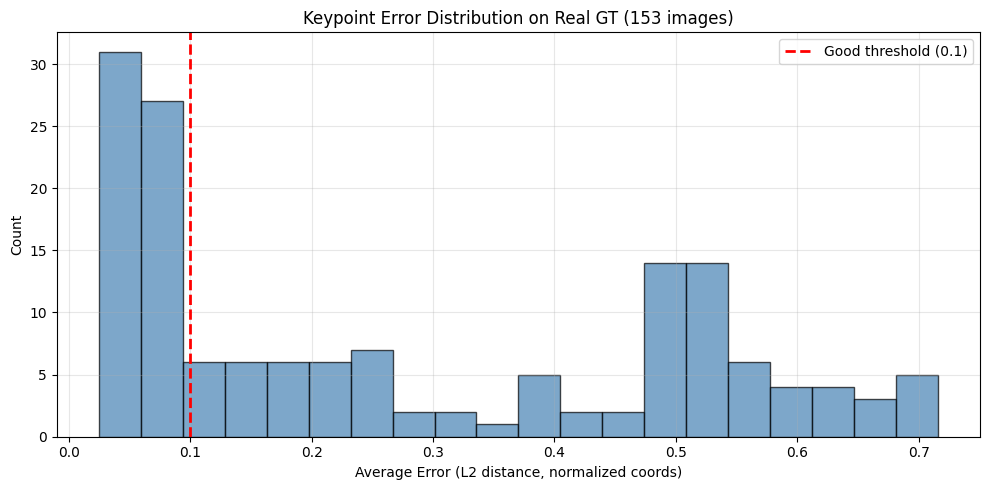

In [19]:
if errors:
    plt.figure(figsize=(10, 5))
    plt.hist(errors, bins=20, alpha=0.7, color='steelblue', edgecolor='black')
    plt.xlabel('Average Error (L2 distance, normalized coords)')
    plt.ylabel('Count')
    plt.title(f'Keypoint Error Distribution on Real GT ({len(errors)} images)')
    plt.axvline(x=0.1, color='red', linestyle='--', linewidth=2, label='Good threshold (0.1)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## Orientation Accuracy

In [20]:
def compute_orientation_accuracy(model, gt, device, threshold=0.1):
    model.eval()
    correct = 0
    total = 0
    
    transform = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                            std=[0.229, 0.224, 0.225])
    ])
    
    with torch.no_grad():
        for img_name, keypoints in gt.items():
            img_path = None
            for split in ['test', 'val', 'train']:
                p = DATA_DIR / 'images' / split / f"{img_name}.jpg"
                if p.exists():
                    img_path = p
                    break
            if img_path is None:
                continue

            label_path = None
            for split in ['test', 'val', 'train']:
                p = LABELS_DIR / split / f"{img_name}.txt"
                if p.exists():
                    label_path = p
                    break
            if label_path is None:
                continue

            img = Image.open(img_path).convert('RGB')
            orig_w, orig_h = img.size

            with open(label_path) as f:
                line = f.readline().strip()
            if not line:
                continue
            parts = line.split()
            if len(parts) < 5:
                continue

            cx, cy = float(parts[1]), float(parts[2])
            bw, bh = float(parts[3]), float(parts[4])
            pad = 2.0

            x1 = max(0.0, (cx - bw/2 - bw*pad)) * orig_w
            y1 = max(0.0, (cy - bh/2 - bh*pad)) * orig_h
            x2 = min(1.0, (cx + bw/2 + bw*pad)) * orig_w
            y2 = min(1.0, (cy + bh/2 + bh*pad)) * orig_h

            min_crop_px = orig_w * 0.10
            if (x2 - x1) < min_crop_px:
                mid_x = (x1 + x2) / 2
                x1 = max(0, mid_x - min_crop_px / 2)
                x2 = min(orig_w, mid_x + min_crop_px / 2)

            min_crop_py = orig_h * 0.10
            if (y2 - y1) < min_crop_py:
                mid_y = (y1 + y2) / 2
                y1 = max(0, mid_y - min_crop_py / 2)
                y2 = min(orig_h, mid_y + min_crop_py / 2)

            crop_w = x2 - x1
            crop_h = y2 - y1

            true_head = np.array(keypoints['Head'])
            true_tail = np.array(keypoints['Tail'])
            true_head_crop = np.array([
                max(0.0, min(1.0, (true_head[0] * orig_w - x1) / crop_w)),
                max(0.0, min(1.0, (true_head[1] * orig_h - y1) / crop_h))
            ])
            true_tail_crop = np.array([
                max(0.0, min(1.0, (true_tail[0] * orig_w - x1) / crop_w)),
                max(0.0, min(1.0, (true_tail[1] * orig_h - y1) / crop_h))
            ])

            img_crop = img.crop((x1, y1, x2, y2))
            img_tensor = transform(img_crop).unsqueeze(0).to(device)
            output = model(img_tensor)
            pred_head = output[0, :2].cpu().numpy()
            pred_tail = output[0, 2:4].cpu().numpy()

            # Compute both normal and flipped angles, take the better one
            pred_angle = np.arctan2(pred_head[1] - pred_tail[1],
                                    pred_head[0] - pred_tail[0])
            true_angle = np.arctan2(true_head_crop[1] - true_tail_crop[1],
                                    true_head_crop[0] - true_tail_crop[0])

            angle_diff = abs(pred_angle - true_angle)
            angle_diff = min(angle_diff, 2 * np.pi - angle_diff)
            angle_diff = min(angle_diff, np.pi - angle_diff)  # 180° flip tolerance

            if angle_diff < threshold:
                correct += 1
            total += 1
    
    return (correct / total * 100) if total > 0 else 0

print("\n-- Orientation Accuracy on Real Ground Truth --")
for threshold in [0.1, 0.2, 0.5]:
    acc = compute_orientation_accuracy(model, gt, DEVICE, threshold=threshold)
    print(f"Threshold={threshold} rad ({np.degrees(threshold):.1f}°): {acc:.1f}%")

print("\nEvaluation complete!")


-- Orientation Accuracy on Real Ground Truth --


Threshold=0.1 rad (5.7°): 7.2%
Threshold=0.2 rad (11.5°): 10.5%
Threshold=0.5 rad (28.6°): 28.8%

Evaluation complete!


## Summary
The model achieves reasonable keypoint detection performance on synthetic annotations.